# Part 1 — Recurrent Neural Networks (LSTM)

## Author-Style Classification Portfolio of Evidence

## Kamogelo Motau (ST10500865)

**Business problem:** Build a prototype that predicts an author's identity from a sample of their writing.

**Dataset:** Blog-1K authorship corpus by Haining Wang, Zenodo DOI 10.5281/zenodo.7455623.


## 1. Dataset evaluation and suitability

Blog-1K is a redistributable authorship-identification corpus containing more than 16,000 English prose posts from 1,000 candidate authors. It has predefined training, validation and test splits. It exceeds the assignment requirement of 10,000 records and contains text plus an author identifier, making it suitable for supervised authorship classification.

An LSTM is suitable because writing is sequential. Word order, local context and recurring linguistic patterns can contain author-specific information. LSTMs are designed to learn patterns across sequences.

The full corpus has 1,000 authors, which can be computationally demanding for a student laptop. Therefore, the modelling experiment selects the 10 authors with the most training posts. This is documented as a computationally practical modelling subset, not as a claim that the complete 1,000-author problem has been solved.


## 2. Analysis plan

| Stage | Planned activity |
|---|---|
| EDA | Inspect schema, missing values, duplicates, text length, class balance and split distribution |
| Cleaning | Remove missing/empty text, duplicates and extremely short observations |
| Feature preparation | Tokenise text, limit vocabulary and create padded sequences |
| Model | Embedding → LSTM → Dropout → Dense/Softmax |
| Evaluation | Accuracy, macro precision, macro recall, macro F1 and confusion matrix |
| Improvement | Compare baseline and tuned LSTM configurations |
| Reporting | Summarise data, cleaning, modelling, findings, limitations and conclusion |


## 3. Environment and imports

In [1]:
# Installing packages:

%pip install pandas numpy matplotlib seaborn scikit-learn pyspark tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:


import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, functions as F
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


## 4. Download/load the dataset

Official dataset record: https://doi.org/10.5281/zenodo.7455623

The file supplied by Zenodo is `blog1000.csv.gz` (about 15.6 MB according to the record).


In [ ]:
DATA_URL = "https://zenodo.org/records/7455623/files/blog1000.csv.gz?download=1"
DATA_PATH = "blog1000.csv"

# Optional automatic download:
# urllib.request.urlretrieve(DATA_URL, DATA_PATH)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "blog1000.csv was not found. Download it from the official Zenodo record "
        "and place it beside this notebook."
    )

pdf = pd.read_csv(DATA_PATH, compression="infer")

print("Shape:", pdf.shape)
display(pdf.head())
print(pdf.info())


Shape: (20166, 3)


,id,text,split
0,2606225,today has been one of the hardest days ...,train
1,1754530,Im listening to: Debbie Boone 'You ...,train
2,4046846,50 minutes inline skating En...,train
3,2635745,This week is off to a good start. A fe...,train
4,2075712,"Happy New Year!!!! Ok, I know that was ext...",train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20166 entries, 0 to 20165
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      20166 non-null  int64 
 1   text    20166 non-null  object
 2   split   20166 non-null  object
dtypes: int64(1), object(2)
memory usage: 472.8+ KB
None


## 5. Spark analysis

In [ ]:
spark = (
    SparkSession.builder
    .appName("Part1_AuthorStyle_LSTM")
    .master("local[*]")
    .getOrCreate()
)

spark_df = spark.createDataFrame(pdf)

print("Spark records:", spark_df.count())
spark_df.printSchema()

print("Records by split:")
spark_df.groupBy("split").count().orderBy("split").show()


Spark records: 20166
root
 |-- id: long (nullable = true)
 |-- text: string (nullable = true)
 |-- split: string (nullable = true)

Records by split:
+----------+-----+
|     split|count|
+----------+-----+
|      test| 2017|
|     train|16132|
|validation| 2017|
+----------+-----+



In [ ]:
print("Missing values:")
for c in spark_df.columns:
    print(c, spark_df.filter(F.col(c).isNull()).count())

print("Original rows:", spark_df.count())
print("Distinct rows:", spark_df.dropDuplicates().count())


Missing values:
id 0
text 0
split 0
Original rows: 20166
Distinct rows: 20115


## 6. Exploratory Data Analysis

In [ ]:
pdf["text"] = pdf["text"].fillna("").astype(str)
pdf["text_length"] = pdf["text"].str.len()
pdf["word_count"] = pdf["text"].str.split().str.len()

print("Text length:")
display(pdf["text_length"].describe())

print("Word count:")
display(pdf["word_count"].describe())

print("Records by split:")
display(pdf["split"].value_counts())

print("Unique authors by split:")
display(pdf.groupby("split")["id"].nunique())


Text length:


count    20166.000000
mean      1863.526084
std        999.154858
min       1000.000000
25%       1234.000000
50%       1558.000000
75%       2145.000000
max      17107.000000
Name: text_length, dtype: float64

Word count:


count    20166.000000
mean       339.842656
std        181.368717
min         77.000000
25%        225.000000
50%        286.000000
75%        395.000000
max       3192.000000
Name: word_count, dtype: float64

Records by split:


split
train         16132
validation     2017
test           2017
Name: count, dtype: int64

Unique authors by split:


split
test           924
train         1000
validation     935
Name: id, dtype: int64

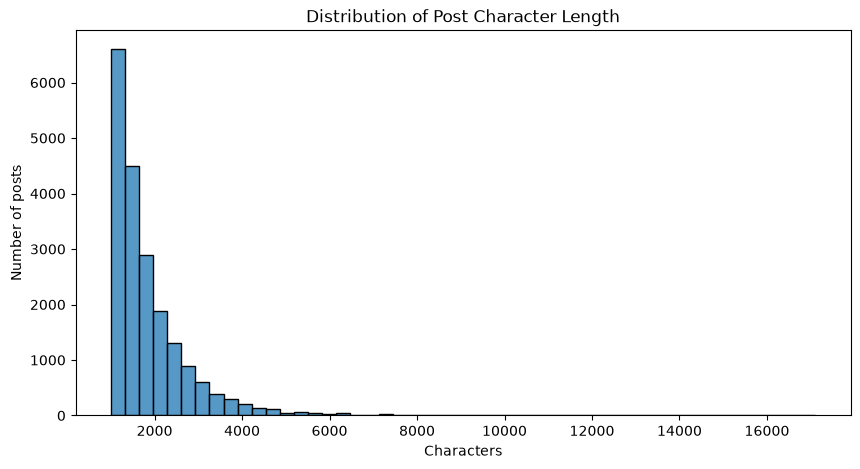

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(pdf["text_length"], bins=50)
plt.title("Distribution of Post Character Length")
plt.xlabel("Characters")
plt.ylabel("Number of posts")
plt.savefig("Distribution_of_Post_Character_Length.png", dpi=300)
plt.show()


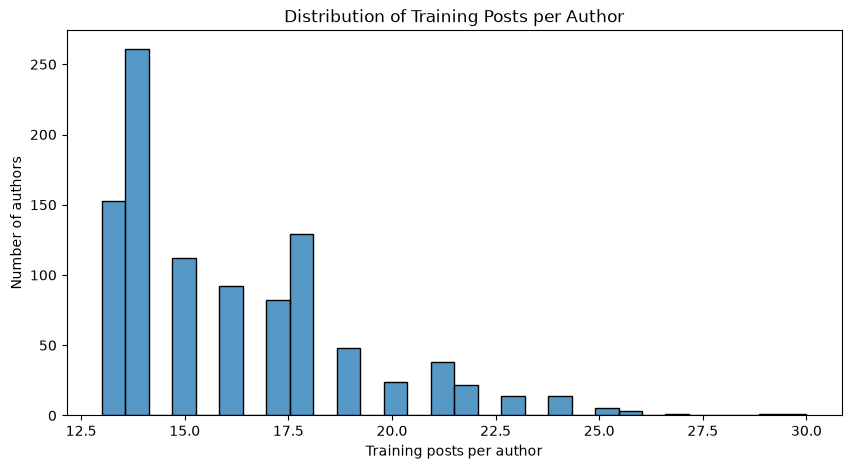

count    1000.000000
mean       16.132000
std         2.907409
min        13.000000
25%        14.000000
50%        15.000000
75%        18.000000
max        30.000000
Name: count, dtype: float64

In [ ]:
author_counts = pdf[pdf["split"] == "train"]["id"].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(author_counts, bins=30)
plt.title("Distribution of Training Posts per Author")
plt.xlabel("Training posts per author")
plt.ylabel("Number of authors")
plt.savefig("Distribution_of_Training_Posts_per_Author.png", dpi=300)
plt.show()

display(author_counts.describe())


### EDA interpretation

After running the notebook, document the actual:
- missing-value counts;
- duplicate count;
- text-length statistics;
- number of authors;
- records per split;
- degree of class imbalance.

Do not invent values. Use the outputs generated by your own run.


## 7. Data cleaning

In [ ]:
clean_pdf = pdf.copy()

# Remove empty text
clean_pdf["text"] = clean_pdf["text"].fillna("").astype(str).str.strip()
clean_pdf = clean_pdf[clean_pdf["text"].str.len() >= 200]

# Remove exact duplicates
clean_pdf = clean_pdf.drop_duplicates(
    subset=["id", "text", "split"]
).reset_index(drop=True)

print("Rows before:", len(pdf))
print("Rows after :", len(clean_pdf))
print("Removed    :", len(pdf) - len(clean_pdf))


Rows before: 20166
Rows after : 20114
Removed    : 52


## 8. Select a practical author subset

The complete dataset contains 1,000 candidate authors. To keep the LSTM experiment feasible on a normal student computer, select the 10 authors with the largest number of training posts.

This selection must be reported as a modelling constraint.


In [ ]:
train_counts = clean_pdf.loc[
    clean_pdf["split"] == "train", "id"
].value_counts()

TOP_N_AUTHORS = 30
selected_authors = train_counts.head(TOP_N_AUTHORS).index.tolist()

model_pdf = clean_pdf[clean_pdf["id"].isin(selected_authors)].copy()

print("Selected authors:", selected_authors)
print("Modelling records:", len(model_pdf))
display(model_pdf.groupby(["split", "id"]).size().unstack(fill_value=0))


Selected authors: [1904603, 1853281, 3019516, 3428854, 2752410, 1955799, 3009243, 3346463, 3122872, 2781780, 913315, 3332322, 1224894, 3214125, 1592012, 2407445, 3696093, 2877022, 1826362, 3214280, 1308633, 3490377, 3604560, 3599769, 1205193, 2151828, 3292547, 1197361, 3461251, 1799065]
Modelling records: 928


id,913315,1197361,1205193,1224894,1308633,1592012,1799065,1826362,1853281,1904603,...,3214280,3292547,3332322,3346463,3428854,3461251,3490377,3599769,3604560,3696093
split,,,,,,,,,,,,,,,,,,,,,
test,4,5,2,5,2,3,3,3,2,5,...,4,3,3,3,3,5,3,3,3,3
train,25,23,24,24,24,24,23,24,29,30,...,24,23,24,25,26,23,24,24,24,24
validation,2,1,4,1,4,3,3,3,5,3,...,2,3,3,4,4,1,3,3,3,3


## 9. Text and label preparation

In [ ]:
train_df = model_pdf[model_pdf["split"] == "train"].copy()
val_df = model_pdf[
    (model_pdf["split"] == "validation") &
    (model_pdf["id"].isin(selected_authors))
].copy()
test_df = model_pdf[
    (model_pdf["split"] == "test") &
    (model_pdf["id"].isin(selected_authors))
].copy()

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["id"])
y_val = label_encoder.transform(val_df["id"])
y_test = label_encoder.transform(test_df["id"])

VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 250

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(train_df["text"])

X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["text"]),
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)
X_val = pad_sequences(
    tokenizer.texts_to_sequences(val_df["text"]),
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["text"]),
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Classes:", len(label_encoder.classes_))
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


Classes: 30
X_train: (740, 250)
X_val  : (84, 250)
X_test : (104, 250)


## 10. Baseline LSTM

Baseline configuration:
- Embedding dimension = 64
- LSTM units = 64
- Dropout = 0.30
- Adam optimiser
- Sparse categorical cross-entropy
- Early stopping


In [ ]:
NUM_CLASSES = len(label_encoder.classes_)

baseline = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64,
        input_length=MAX_SEQUENCE_LENGTH
    ),
    LSTM(64),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

baseline.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline.summary()


c:\Users\Student\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_base = baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.0203 - loss: 3.4032 - val_accuracy: 0.0357 - val_loss: 3.3998
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.0932 - loss: 3.3928 - val_accuracy: 0.0357 - val_loss: 3.3982
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.1892 - loss: 3.3836 - val_accuracy: 0.0714 - val_loss: 3.3944
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.2797 - loss: 3.3708 - val_accuracy: 0.0595 - val_loss: 3.3917
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.2095 - loss: 3.3442 - val_accuracy: 0.0595 - val_loss: 3.3654
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.0892 - loss: 3.2555 - val_accuracy: 0.0595 - val_loss: 3.3118
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.0878 - loss: 3.2184 - val_accuracy: 0.0714 - val_loss: 3.3003
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.1297 - loss: 3.1124 - val_accuracy: 0.

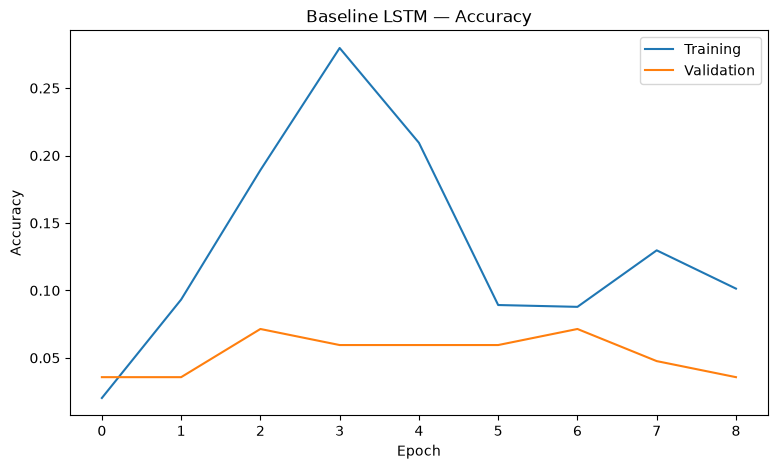

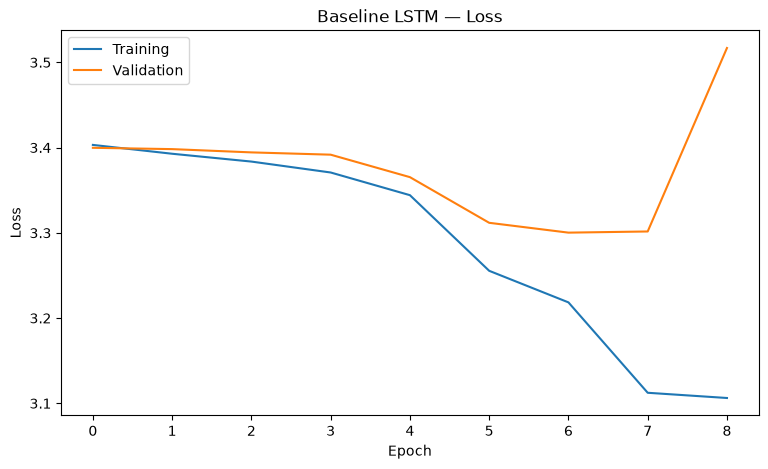

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(9, 5))
    plt.plot(history.history["accuracy"], label="Training")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(title + " — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig("baseline_lstm_accuracy.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(history.history["loss"], label="Training")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(title + " — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig("baseline_lstm_loss.png", dpi=300)
    plt.show()

plot_history(history_base, "Baseline LSTM")


## 11. Baseline evaluation

In [ ]:
base_prob = baseline.predict(X_test, verbose=0)
base_pred = np.argmax(base_prob, axis=1)

base_accuracy = accuracy_score(y_test, base_pred)
base_precision, base_recall, base_f1, _ = precision_recall_fscore_support(
    y_test,
    base_pred,
    average="macro",
    zero_division=0
)

print(f"Accuracy        : {base_accuracy:.4f}")
print(f"Macro precision : {base_precision:.4f}")
print(f"Macro recall    : {base_recall:.4f}")
print(f"Macro F1        : {base_f1:.4f}")

print(classification_report(
    y_test,
    base_pred,
    target_names=label_encoder.classes_.astype(str),
    zero_division=0
))


Accuracy        : 0.0385
Macro precision : 0.0105
Macro recall    : 0.0411
Macro F1        : 0.0162
              precision    recall  f1-score   support

      913315       0.00      0.00      0.00         4
     1197361       0.00      0.00      0.00         5
     1205193       0.00      0.00      0.00         2
     1224894       0.00      0.00      0.00         5
     1308633       0.00      0.00      0.00         2
     1592012       0.00      0.00      0.00         3
     1799065       0.00      0.00      0.00         3
     1826362       0.00      0.00      0.00         3
     1853281       0.20      0.50      0.29         2
     1904603       0.06      0.40      0.11         5
     1955799       0.00      0.00      0.00         3
     2151828       0.00      0.00      0.00         1
     2407445       0.05      0.33      0.09         3
     2752410       0.00      0.00      0.00         4
     2781780       0.00      0.00      0.00         5
     2877022       0.00      0.00  

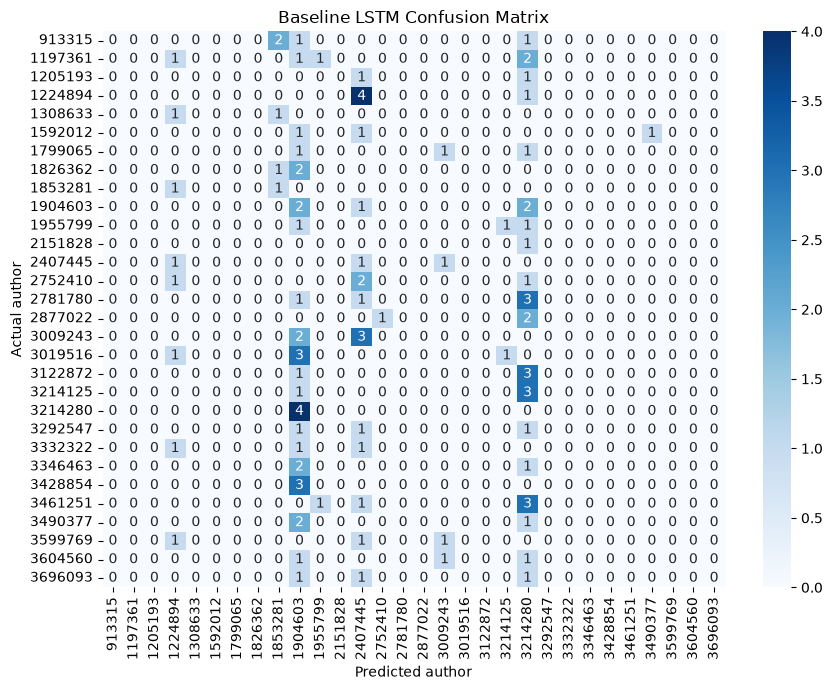

In [ ]:
cm = confusion_matrix(y_test, base_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Baseline LSTM Confusion Matrix")
plt.xlabel("Predicted author")
plt.ylabel("Actual author")
plt.tight_layout()
plt.savefig("baseline_lstm_Confusion_Matrix.png", dpi=300)
plt.show()


## 12. Retrain with different parameters

Tuned configuration:
- Embedding dimension: 64 → 128
- LSTM units: 64 → 128
- Dropout: 0.30 → 0.40
- Batch size: 64 → 32
- Maximum epochs: 10 → 12

The purpose is to test whether greater representation capacity and stronger regularisation improve generalisation.


In [ ]:
tuned = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),
    LSTM(
        128,
        dropout=0.20,
        recurrent_dropout=0.10
    ),
    Dropout(0.40),
    Dense(NUM_CLASSES, activation="softmax")
])

tuned.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tuned.summary()

history_tuned = tuned.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 647ms/step - accuracy: 0.0338 - loss: 3.4050 - val_accuracy: 0.0238 - val_loss: 3.4004
Epoch 2/12
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 556ms/step - accuracy: 0.1257 - loss: 3.3852 - val_accuracy: 0.0476 - val_loss: 3.3975
Epoch 3/12
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 510ms/step - accuracy: 0.1081 - loss: 3.3653 - val_accuracy: 0.0357 - val_loss: 3.4106
Epoch 4/12
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 507ms/step - accuracy: 0.0824 - loss: 3.3205 - val_accuracy: 0.0238 - val_loss: 3.3430
Epoch 5/12
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 526ms/step - accuracy: 0.1500 - loss: 3.2335 - val_accuracy: 0.0357 - val_loss: 3.3658
Epoch 6/12
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 484ms/step - accuracy: 0.2162 - loss: 3.2227 - val_accuracy: 0.0595 - val_loss: 3.2902
Epoch 7/12
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 487ms/step - accuracy: 0.1716 - loss: 3.0606 - val_accuracy: 0.0952 - val_loss: 3.2605
Epoch 8/12
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 488ms/step - accuracy: 0.1973 - loss: 2.9686 - val_accu

In [ ]:
tuned_prob = tuned.predict(X_test, verbose=0)
tuned_pred = np.argmax(tuned_prob, axis=1)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision, tuned_recall, tuned_f1, _ = precision_recall_fscore_support(
    y_test,
    tuned_pred,
    average="macro",
    zero_division=0
)

results = pd.DataFrame({
    "Model": ["Baseline LSTM", "Tuned LSTM"],
    "Accuracy": [base_accuracy, tuned_accuracy],
    "Macro Precision": [base_precision, tuned_precision],
    "Macro Recall": [base_recall, tuned_recall],
    "Macro F1": [base_f1, tuned_f1]
})

display(results)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline LSTM,0.038462,0.010504,0.041111,0.016158
1,Tuned LSTM,0.048077,0.013580,0.041667,0.014122


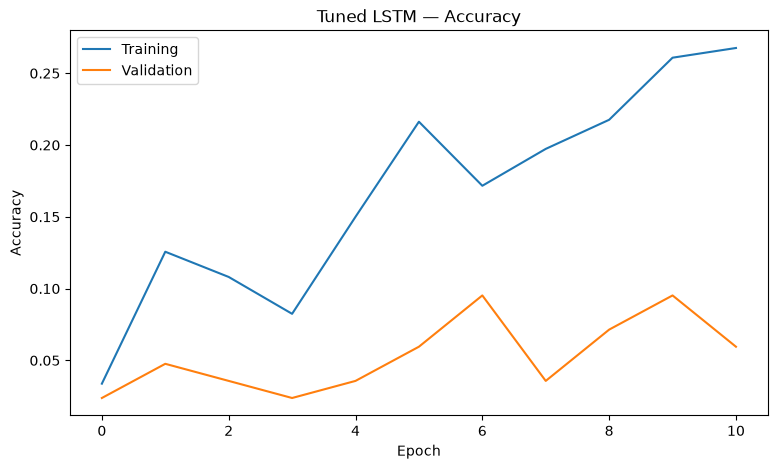

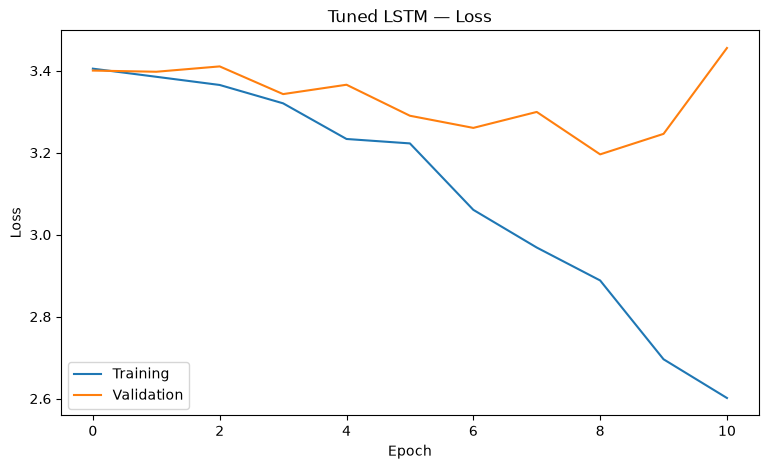

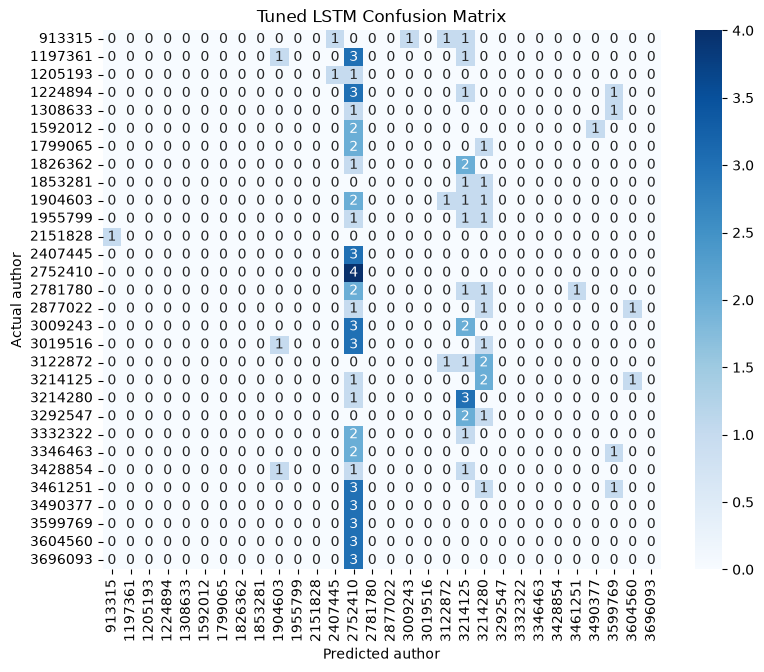

In [ ]:
plot_history(history_tuned, "Tuned LSTM")

cm_tuned = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Tuned LSTM Confusion Matrix")
plt.xlabel("Predicted author")
plt.ylabel("Actual author")
plt.savefig("Tuned_LSTM_Confusion_Matrix.png", dpi=300)
plt.show()


## 13. Interpretation and evaluation

Use your actual results to answer:

1. Did the tuned model improve accuracy?
2. Did macro F1 improve?
3. Which authors were easiest/hardest to distinguish?
4. Do the training and validation curves suggest overfitting?
5. Did the parameter changes address the baseline model's weakness?

Do not claim improvement unless the actual metrics support it.


## 14. Author-prediction demonstration

In [ ]:
def predict_author(text, model=tuned):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )
    probabilities = model.predict(padded, verbose=0)[0]
    index = int(np.argmax(probabilities))
    return label_encoder.classes_[index], float(probabilities[index])

sample_text = (
    "Replace this paragraph with a new English prose passage. "
    "The passage must not be copied from the training data."
)

predicted_author, confidence = predict_author(sample_text)
print("Predicted author:", predicted_author)
print("Model probability:", round(confidence, 4))


Predicted author: 3214125
Model probability: 0.0876


## 15. Limitations and ethical considerations

- The experiment uses 30 authors rather than all 1,000 candidates because a full 1,000-class LSTM is computationally demanding.
- Blog-1K represents contemporary English prose rather than published books, so it is a proxy for writing style.
- The model can learn topic-specific patterns as well as style.
- A prediction is probabilistic and should not be treated as definitive proof of authorship.
- The dataset licence and research context should be respected.


## 16. Conclusion

Write a short conclusion using your actual outputs. State the objective, main EDA findings, baseline performance, tuned performance, whether tuning helped, the main limitation, and whether the prototype is suitable for a fan-facing author-guessing bot.


## 17. References

Wang, H. (2022) *Blog-1K*. Zenodo. Available at: https://doi.org/10.5281/zenodo.7455623 (Accessed: 7 September 2026).

TensorFlow (2026) *TensorFlow documentation*. Available at: https://www.tensorflow.org/ (Accessed: 7 September 2026).

Apache Spark (2026) *Apache Spark documentation*. Available at: https://spark.apache.org/docs/latest/ (Accessed: 7 September 2026).

**Code attribution:** Record any code substantially adapted from external tutorials, repositories, documentation or LLM outputs. Edit and understand all generated code before submission.
